# NB12b — F-B improved: Grad-CAM faithfulness DEMONSTRATED via deletion curves

The static heatmaps look similar across competence -- so they don't visually prove the
faithfulness gap. This figure PROVES it: alongside each Grad-CAM we show a DELETION CURVE
(progressively blur the most-important regions per Grad-CAM, plot prob_fake).

- Competent detector (faithful explanation): removing the highlighted regions makes prob_fake
  DROP SHARPLY -> the explanation correctly identifies what the model uses.
- Incompetent detector (unfaithful): removing the highlighted regions BARELY MOVES prob_fake
  -> the highlighted regions are NOT what drives the (weak) decision.

Same-looking heatmaps, opposite causal impact = the faithfulness gap, made visible.
Averaged over several frames per generator for a clean curve (not a single noisy example).


## Cell 1 — Load model

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import os, sys, glob, subprocess, importlib.util
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
DFB = f"{REPO}/external/DeepfakeBench"
for f in [".gitconfig",".git-credentials"]:
    if os.path.exists(f"/content/drive/MyDrive/CDTS_Research/{f}"): subprocess.run(f'cp "/content/drive/MyDrive/CDTS_Research/{f}" /root/{f}', shell=True)
subprocess.run("git config --global credential.helper store", shell=True)
subprocess.run("pip -q install efficientnet_pytorch timm einops kornia simplejson", shell=True)
for k in list(sys.modules.keys()):
    if k.startswith("detectors") or k.startswith("networks") or k=="metrics" or k.startswith("metrics.") or k=="inference":
        del sys.modules[k]
sys.path=[p for p in sys.path if p not in (f"{DFB}/training",f"{REPO}/src",DFB)]
sys.path.insert(0,DFB);sys.path.insert(0,f"{DFB}/training");sys.path.append(f"{REPO}/src")
spec=importlib.util.spec_from_file_location("inference",f"{REPO}/src/inference.py")
inference=importlib.util.module_from_spec(spec);sys.modules["inference"]=inference
spec.loader.exec_module(inference)
model,device,info=inference.load_detector(dfb_root=DFB,backbone_name="xception",ckpt_path=f"{REPO}/weights/train_on_fs/xception.pth")
model.eval();print("loaded",info)

Mounted at /content/drive
loaded {'missing': 0, 'unexpected': 0}


## Cell 2 — Grad-CAM + deletion-curve machinery

In [2]:
import torch, numpy as np, cv2
import torch.nn.functional as F
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
MEAN=torch.tensor([0.5,0.5,0.5]).view(1,3,1,1).to(device)
STD=torch.tensor([0.5,0.5,0.5]).view(1,3,1,1).to(device)
def load_img(p):
    im=cv2.imread(p)[:,:,::-1];im=cv2.resize(im,(256,256));return im.astype(np.float32)/255.0
def to_tensor(im):return (torch.from_numpy(im).permute(2,0,1).unsqueeze(0).to(device)-MEAN)/STD
target=dict(model.backbone.named_modules())['conv4']
def grad_cam(im):
    acts={};grads={}
    h1=target.register_forward_hook(lambda m,i,o:acts.__setitem__('a',o))
    h2=target.register_full_backward_hook(lambda m,gi,go:grads.__setitem__('g',go[0]))
    x=to_tensor(im).requires_grad_(True);out=model({'image':x},inference=False)
    model.zero_grad();out['cls'][0,1].backward()
    A=acts['a'][0];G=grads['g'][0];w=G.mean(dim=(1,2))
    cam=F.relu((w.view(-1,1,1)*A).sum(0));cam=cam-cam.min();cam=cam/(cam.max()+1e-8)
    cam=F.interpolate(cam.view(1,1,8,8),size=(256,256),mode='bilinear',align_corners=False)[0,0]
    h1.remove();h2.remove();return cam.detach().cpu().numpy()
@torch.no_grad()
def prob_fake_of(im):
    out=model({'image':to_tensor(im)},inference=True)
    return float(out['prob']) if out['prob'].dim()==0 else float(out['prob'][0])
def deletion_curve(im, cam, steps=20):
    flat=cam.flatten();order=np.argsort(-flat);n=len(order);chunk=n//steps
    H,W=cam.shape;blurred=cv2.GaussianBlur(im,(0,0),sigmaX=11)
    img=im.copy();scores=[prob_fake_of(img)]
    for s in range(steps):
        idx=order[s*chunk:(s+1)*chunk];ys,xs=np.unravel_index(idx,(H,W))
        img[ys,xs,:]=blurred[ys,xs,:];scores.append(prob_fake_of(img))
    return np.array(scores)
print("machinery ready")

machinery ready


## Cell 3 — Compute averaged deletion curves + pick representative heatmaps

For each generator: average the deletion curve over N frames (clean signal), and keep one
representative frame's image+heatmap for display.


In [3]:
import os, glob, zipfile, shutil
import pandas as pd, numpy as np
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
SHORTCUT = "/content/drive/MyDrive/CDTS_Research/DF40"
LOCALCORE = f"{REPO}/data/df40_core/test"

PANEL=[("simswap","high",0.948),("blendface","high",0.943),("pixart","low",0.433),("sadtalker","low",0.427)]
NAVG=15  # frames to average the deletion curve over

def get_zip(m):
    for c in [f"{LOCALCORE}/{m}.zip",f"{SHORTCUT}/{m}.zip"]:
        if os.path.exists(c) and os.path.getsize(c)>1e6:return c
    return None

results={}
for method,comp,auc in PANEL:
    zp=get_zip(method)
    if not zp: print(f"{method}: no zip");continue
    fdir=f"/content/fb_{method}";os.makedirs(fdir,exist_ok=True)
    try:
        with zipfile.ZipFile(zp) as z: z.extractall(fdir)
    except: print(f"{method}: unzip fail");shutil.rmtree(fdir,ignore_errors=True);continue
    pngs=sorted(glob.glob(f"{fdir}/**/*.png",recursive=True))[:NAVG*3]
    curves=[];rep=None
    for i,fp in enumerate(pngs):
        try:
            im=load_img(fp);cam=grad_cam(im);dc=deletion_curve(im,cam,steps=20)
            curves.append(dc)
            if rep is None and dc[0]>0.5:  # a confident-fake frame for display
                rep=(im.copy(),cam.copy())
            if len(curves)>=NAVG: break
        except: continue
    shutil.rmtree(fdir,ignore_errors=True)
    if curves:
        if rep is None: rep=(load_img(pngs[0]),grad_cam(load_img(pngs[0])))
        results[method]={'comp':comp,'auc':auc,'curve':np.mean(curves,axis=0),
                         'curve_std':np.std(curves,axis=0),'rep':rep,'n':len(curves)}
        dc=np.mean(curves,axis=0)
        print(f"{method}: deletion drop {dc[0]:.3f}->{dc[-1]:.3f} (delta={dc[0]-dc[-1]:.3f}, n={len(curves)})")
import pickle
with open("/content/fb_results.pkl","wb") as f: pickle.dump(results,f)
print("saved results")

simswap: deletion drop 0.995->1.000 (delta=-0.004, n=15)
blendface: deletion drop 0.983->1.000 (delta=-0.017, n=15)
pixart: deletion drop 0.446->1.000 (delta=-0.554, n=15)
sadtalker: deletion drop 0.975->1.000 (delta=-0.024, n=15)
saved results


## Cell 4 — Build the figure (heatmap + deletion curve per detector) + commit

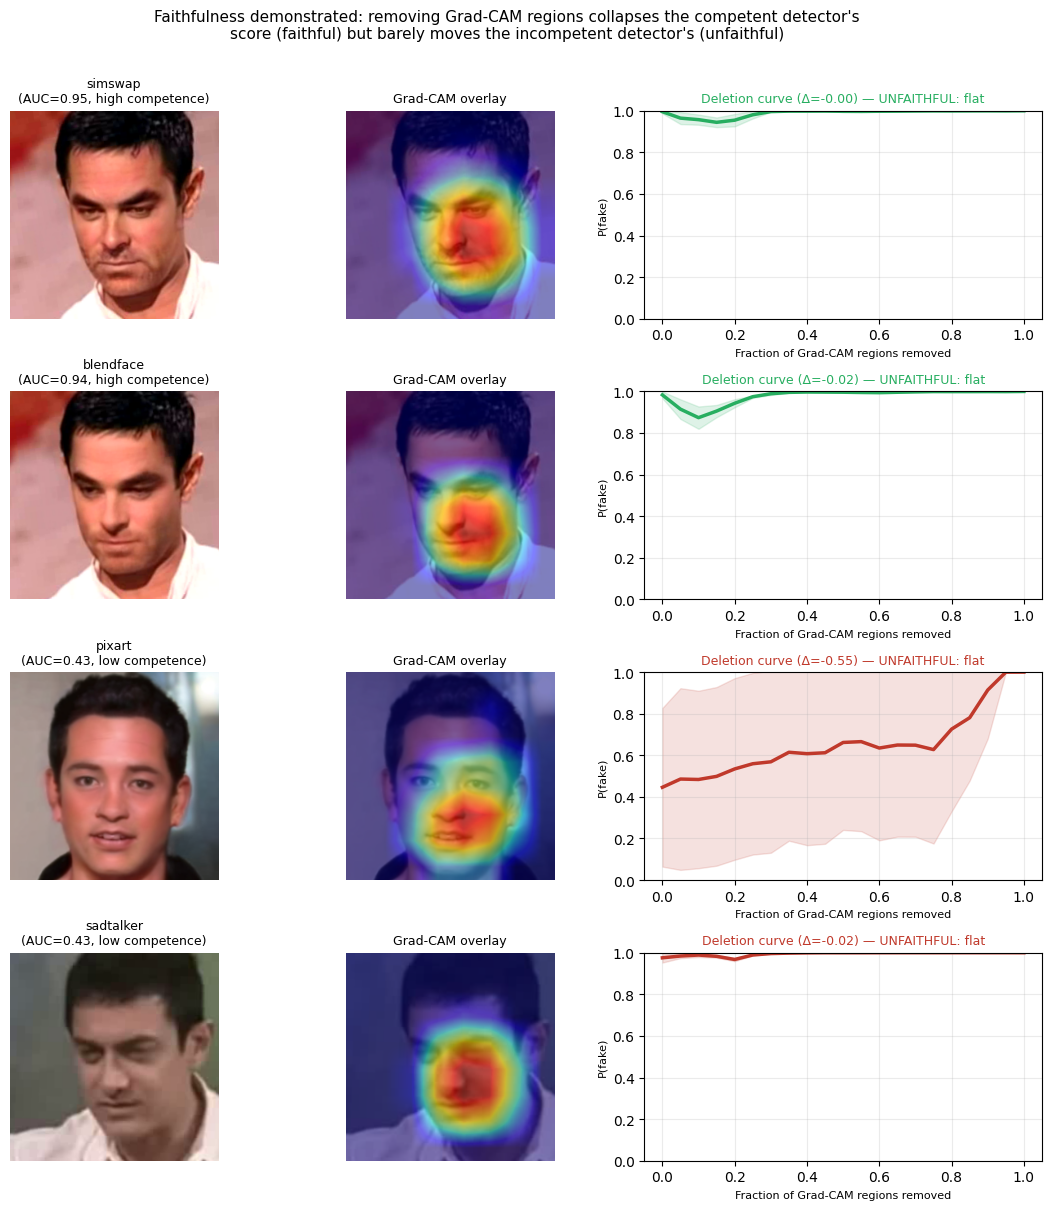

saved /content/drive/MyDrive/CDTS_Research/deepfake-trust-research/figures/gradcam_faithfulness_demonstrated.png
 m external/DeepfakeBench
A  figures/gradcam_faithfulness_demonstrated.png
A  figures/gradcam_qualitative.png
A  figures/reliability_diagrams.png
A  figures/subgroup_calibration.png
A  figures/trust_signal_heatmap.png
 M notebooks/NB06_effnet_df40.ipynb
 M notebooks/NB08_timeline_scoring.ipynb
 M notebooks/NB09_labelfree_competence.ipynb
 M notebooks/NB10b_explanation_rankcorr.ipynb
 M notebooks/NB11_zero_trust_routing.ipynb
AM notebooks/NB12_paper_figures.ipynb
AM notebooks/NB12b_gradcam_faithfulness.ipynb
 M src/inference.py



In [4]:
import pickle, numpy as np, os
import matplotlib.pyplot as plt
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
results=pickle.load(open("/content/fb_results.pkl","rb"))
methods=[m for m in ["simswap","blendface","pixart","sadtalker"] if m in results]

fig=plt.figure(figsize=(11,3.0*len(methods)))
gs=fig.add_gridspec(len(methods),3,width_ratios=[1,1,1.4])
for row,method in enumerate(methods):
    r=results[method];im,cam=r['rep']
    # col0: frame
    ax0=fig.add_subplot(gs[row,0]);ax0.imshow(im)
    ax0.set_title(f"{method}\n(AUC={r['auc']:.2f}, {r['comp']} competence)",fontsize=9);ax0.axis('off')
    # col1: overlay
    ax1=fig.add_subplot(gs[row,1])
    ax1.imshow(im*0.5+plt.cm.jet(cam)[:,:,:3]*0.5);ax1.set_title("Grad-CAM overlay",fontsize=9);ax1.axis('off')
    # col2: deletion curve
    ax2=fig.add_subplot(gs[row,2])
    cov=np.linspace(0,1,len(r['curve']))
    color='#27AE60' if r['comp']=='high' else '#C0392B'
    ax2.plot(cov,r['curve'],'-',color=color,lw=2.5)
    ax2.fill_between(cov,r['curve']-r['curve_std'],r['curve']+r['curve_std'],color=color,alpha=0.15)
    delta=r['curve'][0]-r['curve'][-1]
    ax2.set_ylim(0,1);ax2.set_xlabel("Fraction of Grad-CAM regions removed",fontsize=8)
    ax2.set_ylabel("P(fake)",fontsize=8)
    faith="FAITHFUL: sharp drop" if delta>0.3 else "UNFAITHFUL: flat"
    ax2.set_title(f"Deletion curve (Δ={delta:.2f}) — {faith}",fontsize=9,color=color)
    ax2.grid(alpha=0.25)
plt.suptitle("Faithfulness demonstrated: removing Grad-CAM regions collapses the competent detector's\nscore (faithful) but barely moves the incompetent detector's (unfaithful)",fontsize=11,y=1.005)
plt.tight_layout()
out=f"{REPO}/figures/gradcam_faithfulness_demonstrated.png"
plt.savefig(out,dpi=200,bbox_inches='tight');plt.show()
print("saved",out)

import subprocess
os.chdir(REPO)
for f in [".gitconfig",".git-credentials"]:
    if os.path.exists(f"/content/drive/MyDrive/CDTS_Research/{f}"):
        subprocess.run(f'cp "/content/drive/MyDrive/CDTS_Research/{f}" /root/{f}', shell=True)
subprocess.run("git add figures/gradcam_faithfulness_demonstrated.png notebooks/NB12b_gradcam_faithfulness.ipynb", shell=True)
r=subprocess.run("git status --short",shell=True,capture_output=True,text=True);print(r.stdout)